In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import ast

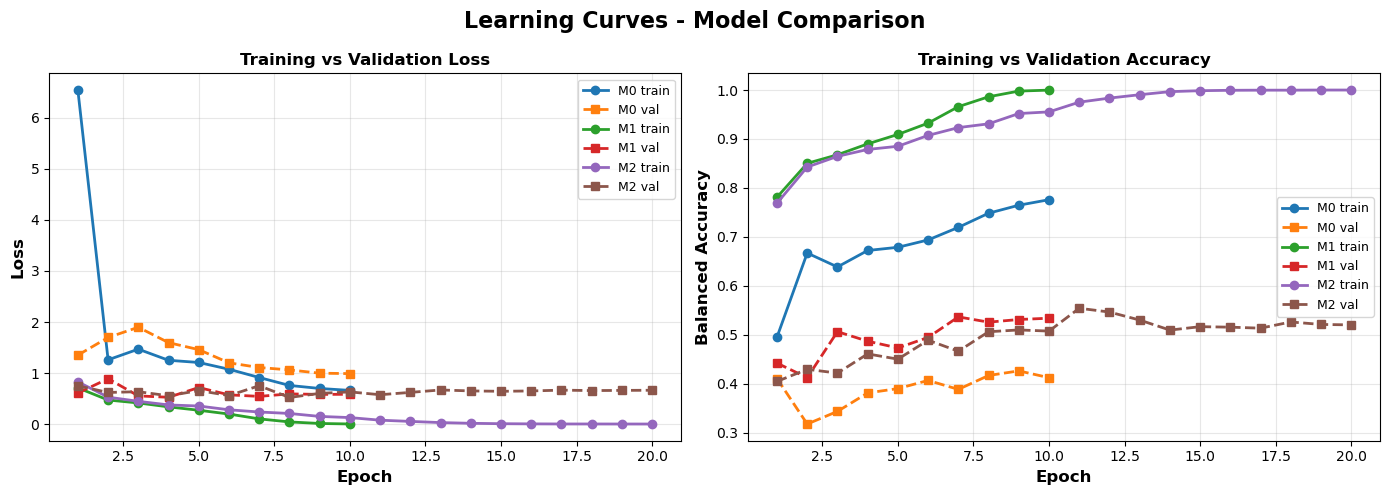

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import re

# ── Load CSVs ──
test_results = pd.read_csv("results/test_results.csv", index_col=0)
res_m1 = pd.read_csv("results/res_m1.csv")
res_m2 = pd.read_csv("results/res_m2.csv")

# ── Parse f1_per_class from numpy string ──
def parse_f1_per_class(s):
    cleaned = re.sub(r'\s+', ' ', str(s).strip())
    nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', cleaned)
    return [float(x) for x in nums]

f1_per_class = {
    col: parse_f1_per_class(test_results.loc["f1_per_class", col])
    for col in test_results.columns
}
num_classes = len(next(iter(f1_per_class.values())))
class_labels = [f"class_{i}" for i in range(num_classes)]  # replace with real names if known

# ── Summary metrics table ──
summary = test_results.drop(index="f1_per_class")
summary = summary.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Table
axes[0].axis("off")
table_data = []
for metric in summary.index:
    row = [metric] + [f"{summary.loc[metric, col]:.4f}" for col in summary.columns]
    table_data.append(row)

tbl = axes[0].table(
    cellText=table_data,
    colLabels=["Metric"] + list(summary.columns),
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 2)

# Highlight best value per row
for row_idx, metric in enumerate(summary.index):
    vals = [float(summary.loc[metric, col]) for col in summary.columns]
    best_col_idx = int(np.argmax(vals)) + 1  # +1 for metric name column
    tbl[row_idx + 1, best_col_idx].set_facecolor("#d4edda")

axes[0].set_title("Test set summary metrics", fontsize=13, pad=12)

# Per-class F1 bar chart
x = np.arange(num_classes)
n_models = len(f1_per_class)
width = 0.8 / n_models
colors = ["#888780", "#378ADD", "#1D9E75"]

for i, (model, vals) in enumerate(f1_per_class.items()):
    offset = (i - n_models / 2 + 0.5) * width
    axes[1].bar(x + offset, vals, width=width, label=model,
                color=colors[i % len(colors)], edgecolor="white", linewidth=0.5)

axes[1].set_xticks(x)
axes[1].set_xticklabels(class_labels, rotation=45, ha="right", fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 score")
axes[1].set_title("Per-class F1 score by model", fontsize=13)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, color in zip(["M1", "M2"], ["#378ADD", "#1D9E75"]):
    try:
        h = pd.read_csv(f"history_{model_name}.csv")
        epochs = range(1, len(h) + 1)
        axes[0].plot(epochs, h["train_loss"], label=f"{model_name} train", color=color)
        axes[0].plot(epochs, h["val_loss"],   label=f"{model_name} val",   color=color, linestyle="--")
        axes[1].plot(epochs, h["train_acc"],  label=f"{model_name} train", color=color)
        axes[1].plot(epochs, h["val_acc"],    label=f"{model_name} val",   color=color, linestyle="--")
    except FileNotFoundError:
        print(f"history_{model_name}.csv not found, skipping.")

axes[0].set_title("Loss");     axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Bal. acc"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()